In [3]:
import os

print(f"Directorul curent: {os.getcwd()}")
calea_noua = "C:/Users/iurie/E_Commers"

try:
    os.chdir(calea_noua)

    print(f"Noul director: {os.getcwd()}")
except FileNotFoundError:
    print(f"Eroare: Directorul '{calea_noua}' nu a fost găsit.")
except Exception as e:
    print(f"A apărut o eroare: {e}")

Directorul curent: C:\Users\iurie
Noul director: C:\Users\iurie\E_Commers


Se incarca fisierul 'E_Commers_jobs_done.json'...
Datele joburilor au fost agregate:
              region_name  job_count
0                  Berlin        391
1  North Rhine-Westphalia        290
2                 Bavaria        249
3       Baden-Württemberg        171
4                 Hamburg        126
Se descarca harta regiunilor de la: https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json

--- Numele Regiunilor din fisierul NOSTRU (JSON) ---
['Baden-Württemberg', 'Bavaria', 'Berlin', 'Brandenburg', 'Bremen', 'Hamburg', 'Hesse', 'Lower Saxony', 'Mecklenburg-West Pomerania', 'North Rhine-Westphalia', 'Renania de Nord-Westfalia', 'Rhineland-Palatinate', 'Saarland', 'Saxony', 'Saxony-Anhalt', 'Schleswig-Holstein', 'Thuringia']

--- Numele Regiunilor din fisierul Hartii (GeoJSON) ---
['Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 

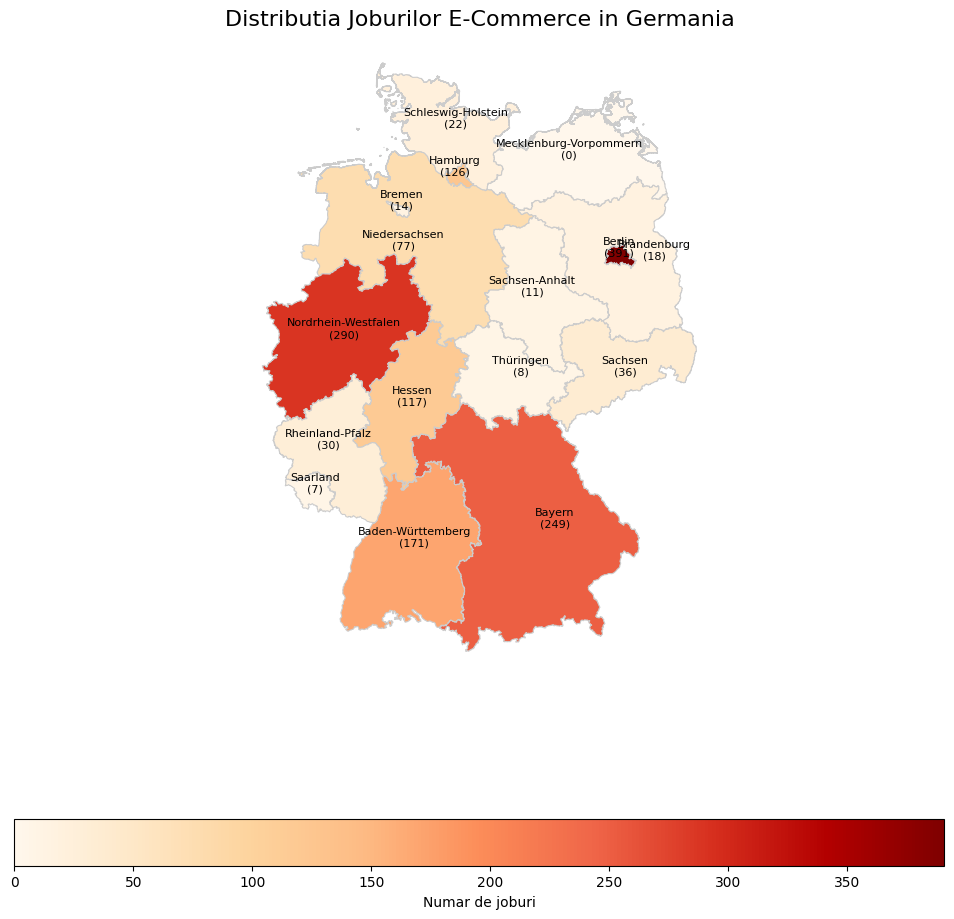

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Pasul 1: Incarcarea si pregatirea datelor ---

print("Se incarca fisierul 'E_Commers_jobs_done.json'...")
# Incarcam joburile noastre
df = pd.read_json('E_Commers_jobs_done.json')

# Numaram joburile pentru fiecare regiune
jobs_per_region = df['region'].value_counts().reset_index()
jobs_per_region.columns = ['region_name', 'job_count']

print("Datele joburilor au fost agregate:")
print(jobs_per_region.head())

# --- Pasul 2: Incarcarea hartii (GeoJSON) ---

# Vom folosi un fisier GeoJSON al landurilor germane direct de pe net
# Sursa: https://github.com/isellsoap/deutschlandGeoJSON
url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
print(f"Se descarca harta regiunilor de la: {url_geojson}")
gdf_lander = gpd.read_file(url_geojson)

# --- Pasul 3: Diagnoza potrivirii numelor ---
# Aceasta este CEA MAI IMPORTANTA parte

# Verificam ce nume avem noi:
nume_din_json = sorted(jobs_per_region['region_name'].unique())
print("\n--- Numele Regiunilor din fisierul NOSTRU (JSON) ---")
print(nume_din_json)

# Verificam ce nume are harta:
# (Coloana 'name' este cea care contine numele landurilor in acest GeoJSON)
nume_din_harta = sorted(gdf_lander['name'].unique())
print("\n--- Numele Regiunilor din fisierul Hartii (GeoJSON) ---")
print(nume_din_harta)

# --- Pasul 4: Corectarea numelor (Exemplu) ---
# Vei observa diferente, de ex:
# JSON: 'North Rhine-Westphalia' vs. Harta: 'Nordrhein-Westfalen'
# JSON: 'Bavaria' vs. Harta: 'Bayern'
# JSON: 'Hesse' vs. Harta: 'Hessen'

# Trebuie sa le mapam. Cream un dictionar de corectii:
corectii_nume = {
    "North Rhine-Westphalia": "Nordrhein-Westfalen",
    "Bavaria": "Bayern",
    "Hesse": "Hessen",
    "Lower Saxony": "Niedersachsen",
    "Rhineland-Palatinate": "Rheinland-Pfalz",
    "Baden-Württemberg": "Baden-Württemberg", # Acesta e corect, dar il punem pentru siguranta
    "Saxony": "Sachsen",
    "Thuringia": "Thüringen",
    "Saxony-Anhalt": "Sachsen-Anhalt",
    "Mecklenburg-Vorpommern": "Mecklenburg-Vorpommern"
    # Adauga aici si altele pe care le gasesti
}

print("\nSe corecteaza numele regiunilor...")
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name'].map(corectii_nume)

# Lasam "Berlin" si "Hamburg" asa cum sunt, ele sunt si in harta
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name_corectat'].fillna(jobs_per_region['region_name'])


# --- Pasul 5: Unirea (Merge) datelor ---
# Unim harta (gdf_lander) cu datele noastre (jobs_per_region)
# folosind numele corectate
print("Se unesc datele cu harta...")
merged_gdf = gdf_lander.merge(
    jobs_per_region,
    left_on='name',
    right_on='region_name_corectat',
    how='left'
)

# Umplem regiunile fara joburi cu 0, in loc de 'NaN'
merged_gdf['job_count'] = merged_gdf['job_count'].fillna(0)

# --- Pasul 6: Crearea graficului ---
print("Se genereaza harta...")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Deseneaza harta
merged_gdf.plot(
    column='job_count',      # Coloana dupa care se coloreaza
    cmap='OrRd',             # Schema de culori (Orange-Red)
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Numar de joburi", 'orientation': "horizontal"}
)

# Adaugam etichete cu numele regiunilor
merged_gdf.apply(lambda x: ax.annotate(text=f"{x['name']}\n({int(x['job_count'])})",
                                        xy=x.geometry.representative_point().coords[0],
                                        ha='center', fontsize=8), axis=1)

# Curatarea finala
ax.set_axis_off()
ax.set_title(
    'Distributia Joburilor E-Commerce in Germania',
    fontdict={'fontsize': '16', 'fontweight' : '3'}
)

# Salvarea hartii
plt.savefig("harta_choropleth_regiuni.png")
print("\nSucces! Harta a fost salvata ca 'harta_choropleth_regiuni.png'")

# Afiseaza harta
plt.show()

Loading 'E_Commers_jobs_done.json'...
Job data has been aggregated:
              region_name  job_count
0                  Berlin        391
1  North Rhine-Westphalia        290
2                 Bavaria        249
3       Baden-Württemberg        171
4                 Hamburg        126
Correcting region names for matching...
Merging job data with the map...
Generating the map...
Adding dynamic text labels...

Success! Map saved as 'harta_choropleth_regiuni_v2.png'


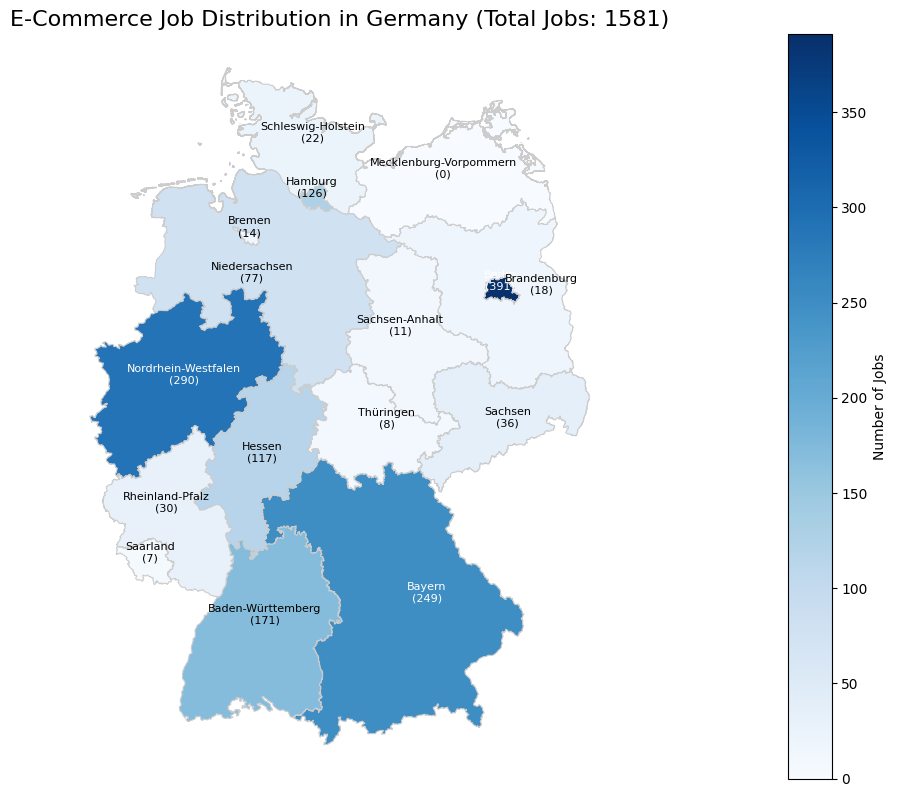

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable # For the vertical legend

# --- Step 1: Load and prepare data ---

print("Loading 'E_Commers_jobs_done.json'...")
# Load our jobs
df = pd.read_json('E_Commers_jobs_done.json')

# Get total job count for the title
total_jobs = len(df)

# Count jobs per region
jobs_per_region = df['region'].value_counts().reset_index()
jobs_per_region.columns = ['region_name', 'job_count']

print("Job data has been aggregated:")
print(jobs_per_region.head())

# --- Step 2: Load the map (GeoJSON) ---

# We'll use a GeoJSON file of German states (Länder) directly from the web
# Source: https://github.com/isellsoap/deutschlandGeoJSON
url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
print(f"Downloading region map from: {url_geojson}")
gdf_lander = gpd.read_file(url_geojson)

# --- Step 3: Name matching (The core data analysis task) ---
# We must match our names (e.g., "Bavaria") to the map's names (e.g., "Bayern")

# Create a correction dictionary
corectii_nume = {
    "North Rhine-Westphalia": "Nordrhein-Westfalen",
    "Bavaria": "Bayern",
    "Hesse": "Hessen",
    "Lower Saxony": "Niedersachsen",
    "Rhineland-Palatinate": "Rheinland-Pfalz",
    "Baden-Württemberg": "Baden-Württemberg",
    "Saxony": "Sachsen",
    "Thuringia": "Thüringen",
    "Saxony-Anhalt": "Sachsen-Anhalt",
    "Mecklenburg-Vorpommern": "Mecklenburg-Vorpommern"
    # 'Berlin', 'Hamburg', 'Bremen' etc. are usually the same
}

print("Correcting region names for matching...")
# Create a new corrected column
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name'].map(corectii_nume)
# If a name was not in the dictionary (e.g., 'Berlin'), fill it with its original name
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name_corectat'].fillna(jobs_per_region['region_name'])


# --- Step 4: Merge the data ---
print("Merging job data with the map...")
merged_gdf = gdf_lander.merge(
    jobs_per_region,
    left_on='name',
    right_on='region_name_corectat',
    how='left'
)

# Fill regions with no jobs with 0 instead of 'NaN'
merged_gdf['job_count'] = merged_gdf['job_count'].fillna(0)

# --- Step 5: Create the plot ---
print("Generating the map...")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# --- Vertical Legend Setup ---
# Create a divider for the existing axes
divider = make_axes_locatable(ax)
# Append a new axes to the right (5% of main ax width) for the legend
cax = divider.append_axes("right", size="5%", pad=0.1)

# Get min/max values for dynamic text coloring
vmin = merged_gdf['job_count'].min()
vmax = merged_gdf['job_count'].max()

# Plot the main map
merged_gdf.plot(
    column='job_count',      # Column to color by
    cmap='Blues',            # NEW: 'Blues' colormap
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    cax=cax,                 # Use the dedicated axes for the legend
    legend_kwds={'label': "Number of Jobs"} # Legend label
)

# --- Dynamic Text Labels ---
# Add labels with region names and counts
print("Adding dynamic text labels...")
merged_gdf.apply(lambda x: ax.annotate(
    text=f"{x['name']}\n({int(x['job_count'])})",
    xy=x.geometry.representative_point().coords[0],
    ha='center',
    fontsize=8,
    # NEW: Dynamic color based on value
    color='white' if x['job_count'] > (vmax * 0.5) else 'black'
), axis=1)

# --- Final Cleanup ---
ax.set_axis_off()

# NEW: Title with total job count
ax.set_title(
    f'E-Commerce Job Distribution in Germany (Total Jobs: {total_jobs})',
    fontdict={'fontsize': '16', 'fontweight' : '3'}
)

# Save the map
plt.savefig("harta_choropleth_regiuni_v2.png", dpi=300)
print("\nSuccess! Map saved as 'harta_choropleth_regiuni_v2.png'")

# Show the map
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Step 1: Load and prepare data ---

print("Loading 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')

total_jobs = len(df)
jobs_per_region = df['region'].value_counts().reset_index()
jobs_per_region.columns = ['region_name', 'job_count']

print("Job data has been aggregated:")
print(jobs_per_region.head())

# --- Step 2: Load the map (GeoJSON) ---

url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
print(f"Downloading region map from: {url_geojson}")
gdf_lander = gpd.read_file(url_geojson)

# --- Step 3: Name matching ---
corectii_nume = {
    "North Rhine-Westphalia": "Nordrhein-Westfalen",
    "Bavaria": "Bayern",
    "Hesse": "Hessen",
    "Lower Saxony": "Niedersachsen",
    "Rhineland-Palatinate": "Rheinland-Pfalz",
    "Baden-Württemberg": "Baden-Württemberg",
    "Saxony": "Sachsen",
    "Thuringia": "Thüringen",
    "Saxony-Anhalt": "Sachsen-Anhalt",
    "Mecklenburg-Vorpommern": "Mecklenburg-Vorpommern",
    "Schleswig-Holstein": "Schleswig-Holstein", # Added for completeness
    "Brandenburg": "Brandenburg",
    "Bremen": "Bremen",
    "Hamburg": "Hamburg",
    "Saarland": "Saarland"
    # Ensure all possible regions from your data are mapped
}

print("Correcting region names for matching...")
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name'].map(corectii_nume)
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name_corectat'].fillna(jobs_per_region['region_name'])


# --- Step 4: Merge the data ---
print("Merging job data with the map...")
merged_gdf = gdf_lander.merge(
    jobs_per_region,
    left_on='name',
    right_on='region_name_corectat',
    how='left'
)
merged_gdf['job_count'] = merged_gdf['job_count'].fillna(0)

# --- Step 5: Create the plot ---
print("Generating the map...")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

vmin = merged_gdf['job_count'].min()
vmax = merged_gdf['job_count'].max()

merged_gdf.plot(
    column='job_count',
    cmap='Blues',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    cax=cax,
    legend_kwds={'label': "Number of Jobs"}
)

# --- Dynamic Text Labels and Special Handling for Berlin ---
print("Adding dynamic text labels...")

# Define custom text positions for problematic regions (manual adjustment)
custom_text_positions = {
    "Berlin": {"xytext": (20, -20), "arrowprops": dict(facecolor='black', arrowstyle="->", lw=0.5)},
    "Bremen": {"xytext": (-10, -30), "arrowprops": dict(facecolor='black', arrowstyle="->", lw=0.5)},
    "Hamburg": {"xytext": (0, 30), "arrowprops": dict(facecolor='black', arrowstyle="->", lw=0.5)},
    "Saarland": {"xytext": (20, 20), "arrowprops": dict(facecolor='black', arrowstyle="->", lw=0.5)}
}

for idx, row in merged_gdf.iterrows():
    region_name = row['name']
    job_count = int(row['job_count'])
    
    # Text content for the label
    label_text = f"{region_name}\n({job_count})"
    
    # Get representative point for the arrow/base text position
    xy_coords = row.geometry.representative_point().coords[0]
    
    # Determine text color based on job count (dynamic contrast)
    text_color = 'white' if job_count > (vmax * 0.5) else 'black'
    
    if region_name in custom_text_positions:
        # Use annotate for problematic regions with arrows
        ax.annotate(
            text=label_text,
            xy=xy_coords,
            xytext=custom_text_positions[region_name]["xytext"],
            textcoords="offset points",
            arrowprops=custom_text_positions[region_name]["arrowprops"],
            ha='center',
            fontsize=8,
            color=text_color,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7) # Added a bbox for readability
        )
    else:
        # For other regions, use simple text annotation
        ax.annotate(
            text=label_text,
            xy=xy_coords,
            ha='center',
            fontsize=8,
            color=text_color
        )

# --- Final Cleanup ---
ax.set_axis_off()
ax.set_title(
    f'E-Commerce Job Distribution in Germany (Total Jobs: {total_jobs})',
    fontdict={'fontsize': '16', 'fontweight' : '3'}
)

# Save the map
plt.savefig("harta_choropleth_regiuni_v3.png", dpi=300, bbox_inches='tight') # bbox_inches='tight' helps with labels at edges
print("\nSuccess! Map saved as 'harta_choropleth_regiuni_v3.png'")

# Show the map
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Step 1: Load and prepare data ---

print("Loading 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')

total_jobs = len(df)
jobs_per_region = df['region'].value_counts().reset_index()
jobs_per_region.columns = ['region_name', 'job_count']

print("Job data has been aggregated:")
print(jobs_per_region.head())

# --- Step 2: Load the map (GeoJSON) ---

url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
print(f"Downloading region map from: {url_geojson}")
gdf_lander = gpd.read_file(url_geojson)

# --- Step 3: Name matching ---
corectii_nume = {
    "North Rhine-Westphalia": "Nordrhein-Westfalen",
    "Bavaria": "Bayern",
    "Hesse": "Hessen",
    "Lower Saxony": "Niedersachsen",
    "Rhineland-Palatinate": "Rheinland-Pfalz",
    "Baden-Württemberg": "Baden-Württemberg",
    "Saxony": "Sachsen",
    "Thuringia": "Thüringen",
    "Saxony-Anhalt": "Sachsen-Anhalt",
    "Mecklenburg-Vorpommern": "Mecklenburg-Vorpommern",
    "Schleswig-Holstein": "Schleswig-Holstein",
    "Brandenburg": "Brandenburg",
    "Bremen": "Bremen",
    "Hamburg": "Hamburg",
    "Saarland": "Saarland",
    "Berlin": "Berlin"
}

print("Correcting region names for matching...")
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name'].map(corectii_nume)
jobs_per_region['region_name_corectat'] = jobs_per_region['region_name_corectat'].fillna(jobs_per_region['region_name'])

# --- Step 4: Merge the data ---
print("Merging job data with the map...")
merged_gdf = gdf_lander.merge(
    jobs_per_region,
    left_on='name',
    right_on='region_name_corectat',
    how='left'
)
merged_gdf['job_count'] = merged_gdf['job_count'].fillna(0)

# --- Step 5: Create the plot ---
print("Generating the map...")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

vmin = merged_gdf['job_count'].min()
vmax = merged_gdf['job_count'].max()

merged_gdf.plot(
    column='job_count',
    cmap='Blues',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    cax=cax,
    legend_kwds={'label': "Number of Jobs"}
)

# --- Dynamic Text Labels and Special Handling for Berlin ---
print("Adding dynamic text labels...")

# Custom position ONLY for Berlin
custom_text_positions = {
    "Berlin": {
        "xytext": (20, -20), # Offset text position
        "arrowprops": dict(facecolor='black', arrowstyle="->", lw=0.5),
        # NEW: Dark background box for white text
        "bbox": dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.7)
    }
}

for idx, row in merged_gdf.iterrows():
    region_name = row['name']
    job_count = int(row['job_count'])
    
    label_text = f"{region_name}\n({job_count})"
    xy_coords = row.geometry.representative_point().coords[0]
    
    # Dynamic text color for contrast
    text_color = 'white' if job_count > (vmax * 0.5) else 'black'
    
    # --- NEW LOGIC ---
    if region_name == "Berlin":
        # Apply special rules for Berlin
        ax.annotate(
            text=label_text,
            xy=xy_coords,
            xytext=custom_text_positions[region_name]["xytext"],
            textcoords="offset points",
            arrowprops=custom_text_positions[region_name]["arrowprops"],
            ha='center',
            fontsize=8,
            color=text_color, # Will be 'white' based on dynamic logic
            bbox=custom_text_positions[region_name]["bbox"]
        )
    else:
        # Apply standard centered text for ALL other regions
        ax.annotate(
            text=label_text,
            xy=xy_coords,
            ha='center',
            fontsize=8,
            color=text_color
        )

# --- Final Cleanup ---
ax.set_axis_off()
ax.set_title(
    f'E-Commerce Job Distribution in Germany (Total Jobs: {total_jobs})',
    fontdict={'fontsize': '16', 'fontweight' : '3'}
)

# Save the map
plt.savefig("harta_choropleth_regiuni_final.png", dpi=300, bbox_inches='tight')
print("\nSuccess! Map saved as 'harta_choropleth_regiuni_final.png'")

# Show the map
plt.show()

Se incarca fisierul 'E_Commers_jobs_done.json'...
Am agregat datele. Vom afisa Top 50 orase.
Se initializeaza serviciul de geocoding (Nominatim/OpenStreetMap)...
Incep geocoding-ul pentru top orase (poate dura 1-2 minute)...
  Gasit: Berlin -> (52.5173885, 13.3951309)
  Gasit: Hamburg -> (53.550341, 10.000654)
  Gasit: Munich -> (48.1371079, 11.5753822)
  Gasit: Cologne -> (50.938361, 6.959974)
  Gasit: Düsseldorf -> (51.2254018, 6.7763137)
  Gasit: Frankfurt -> (50.1106444, 8.6820917)
  Gasit: Stuttgart -> (48.7784485, 9.1800132)
  Gasit: Frankfurt am Main -> (50.1106444, 8.6820917)
  Gasit: Leipzig -> (51.3406321, 12.3747329)
  Gasit: Göttingen -> (51.5328328, 9.9351811)
  Gasit: Bremen -> (53.0758196, 8.8071646)
  Gasit: Münster -> (51.9625101, 7.6251879)
  Gasit: Dresden -> (51.0493286, 13.7381437)
  Gasit: Dortmund -> (51.5142273, 7.4652789)
  Gasit: Karlsruhe -> (49.0068705, 8.4034195)
  Gasit: Nuremberg -> (49.453872, 11.077298)
  Gasit: Würzburg -> (49.7780356, 9.9434769)
  Gas

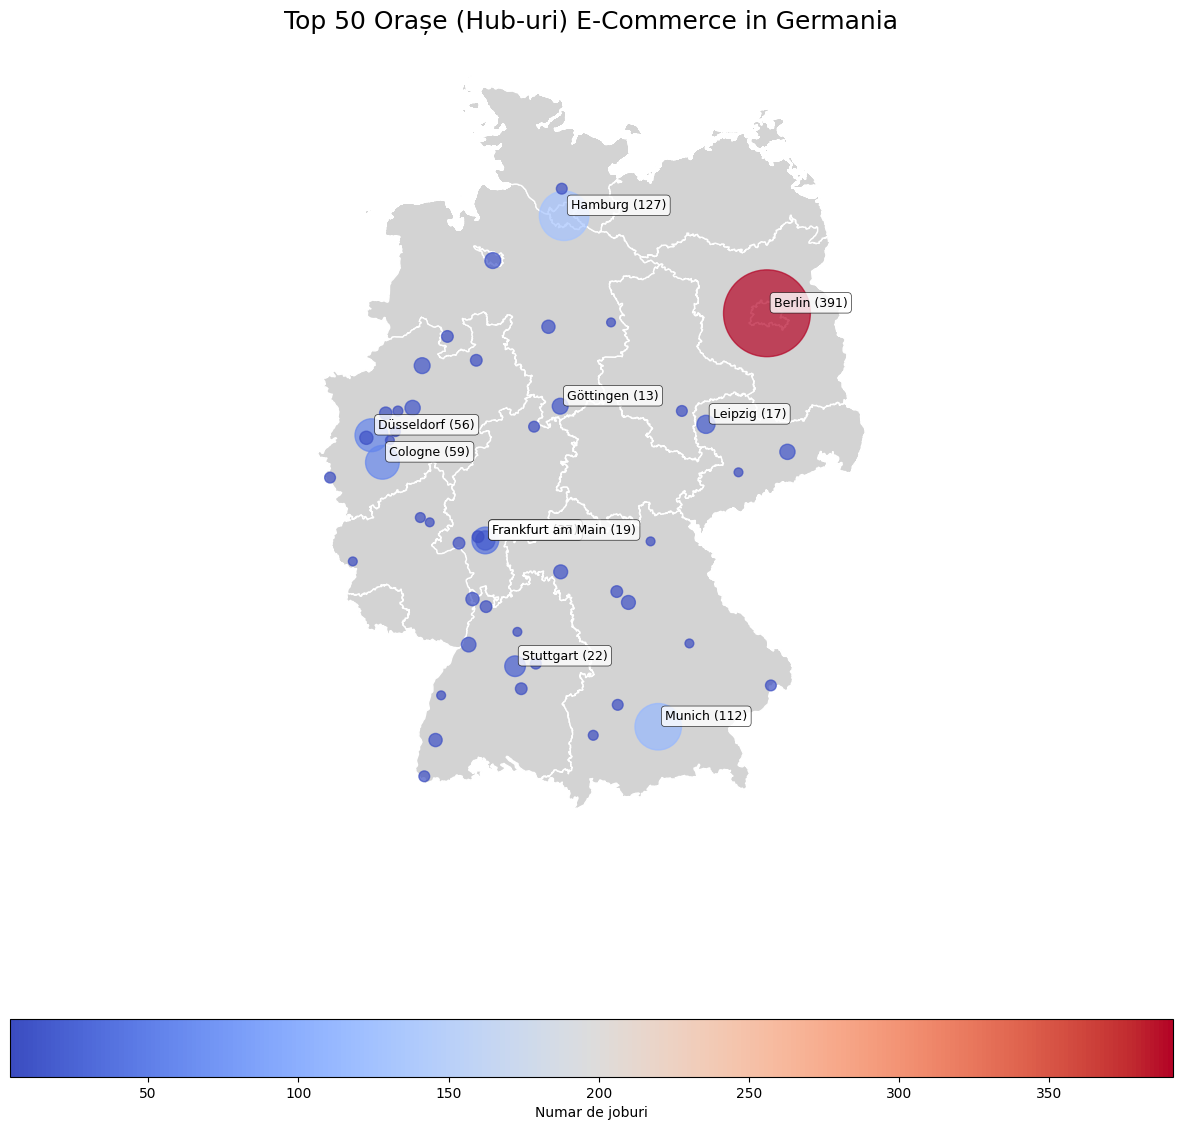

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

# --- Pasul 1: Incarcarea si agregarea datelor ---
print("Se incarca fisierul 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')

# Numaram joburile pentru fiecare oras
jobs_per_city = df['city'].value_counts().reset_index()
jobs_per_city.columns = ['city_name', 'job_count']

# Pastram doar Top 50 orase, pentru a nu supraincarca harta si geocoding-ul
top_cities = jobs_per_city.head(50).copy()
print(f"Am agregat datele. Vom afisa Top {len(top_cities)} orase.")

# --- Pasul 2: Geocoding (Obtinerea coordonatelor) ---
print("Se initializeaza serviciul de geocoding (Nominatim/OpenStreetMap)...")
# ATENTIE: Defineste un user_agent unic
geolocator = Nominatim(user_agent="my-ecommerce-portfolio-v1")
# Folosim un RateLimiter pentru a nu fi blocati (1 secunda intre cereri)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Functie pentru a obtine coordonatele
def get_coords(city_name):
    # Cautam doar in Germania pentru precizie
    query = f"{city_name}, Germany"
    try:
        location = geocode(query)
        if location:
            print(f"  Gasit: {city_name} -> ({location.latitude}, {location.longitude})")
            return location.latitude, location.longitude
    except Exception as e:
        print(f"  Eroare la geocoding pentru {city_name}: {e}")
    print(f"  NEGASIT: {city_name}")
    return None, None

print("Incep geocoding-ul pentru top orase (poate dura 1-2 minute)...")
# Aplicam functia pe dataframe
coords = top_cities['city_name'].apply(get_coords)
top_cities['latitude'] = [c[0] for c in coords]
top_cities['longitude'] = [c[1] for c in coords]

# Curatam orasele pe care nu le-am gasit
top_cities = top_cities.dropna(subset=['latitude', 'longitude'])
print("Geocoding finalizat.")

# --- Pasul 3: Conversia in GeoDataFrame ---
# Convertim tabelul pandas intr-un GeoDataFrame,
# specificand ca geometria este bazata pe puncte (lat/lon)
gdf_cities = gpd.GeoDataFrame(
    top_cities,
    geometry=gpd.points_from_xy(top_cities.longitude, top_cities.latitude),
    crs="EPSG:4326" # CRS standard pentru lat/lon
)

# --- Pasul 4: Incarcarea hartii de baza ---
# Folosim aceeasi harta a landurilor ca fundal
url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
gdf_lander = gpd.read_file(url_geojson)

# --- Pasul 5: Crearea graficului ---
print("Se genereaza harta cu bule...")
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Desenam fundalul (harta Germaniei)
gdf_lander.plot(
    ax=ax,
    color='lightgray',
    edgecolor='white'
)

# Desenam bulele (orasele)
# Marimea (markersize) este proportionala cu 'job_count'
gdf_cities.plot(
    ax=ax,
    markersize=gdf_cities['job_count'] * 10, # Poti ajusta multiplicatorul (10)
    column='job_count',
    cmap='coolwarm', # Schema de culori
    legend=True,
    alpha=0.7,
    legend_kwds={'label': "Numar de joburi", 'orientation': "horizontal"}
)

# Adaugam etichete pentru Top 10 orase
top_10 = gdf_cities.nlargest(10, 'job_count')
for x, y, label, count in zip(top_10.geometry.x, top_10.geometry.y, top_10["city_name"], top_10["job_count"]):
    # Adnotam cu o mica sageata
    ax.annotate(
        f"{label} ({count})",
        xy=(x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.8)
    )

# Curatarea finala
ax.set_axis_off()
ax.set_title(
    'Top 50 Orașe (Hub-uri) E-Commerce in Germania',
    fontdict={'fontsize': '18', 'fontweight' : '3'}
)

# Salvarea hartii
plt.savefig("harta_bule_orase.png")
print("\nSucces! Harta a fost salvata ca 'harta_bule_orase.png'")

# Afiseaza harta
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

# --- Step 1: Load and aggregate data ---
print("Loading 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')

jobs_per_city = df['city'].value_counts().reset_index()
jobs_per_city.columns = ['city_name', 'job_count']

# We'll plot the Top 50 cities
top_cities_to_plot = jobs_per_city.head(50).copy()
print(f"Aggregated data. Plotting Top {len(top_cities_to_plot)} cities.")

# --- Step 2: Geocoding (Getting coordinates) ---
print("Initializing geocoding service (Nominatim/OpenStreetMap)...")
geolocator = Nominatim(user_agent="my-ecommerce-portfolio-v3-opt1")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coords(city_name):
    query = f"{city_name}, Germany"
    try:
        location = geocode(query)
        if location:
            print(f"  Found: {city_name} -> ({location.latitude}, {location.longitude})")
            return location.latitude, location.longitude
    except Exception as e:
        print(f"  Geocoding error for {city_name}: {e}")
    print(f"  NOT FOUND: {city_name}")
    return None, None

print("Starting geocoding for top cities (this may take 1-2 minutes)...")
coords = top_cities_to_plot['city_name'].apply(get_coords)
top_cities_to_plot['latitude'] = [c[0] for c in coords]
top_cities_to_plot['longitude'] = [c[1] for c in coords]

top_cities_to_plot = top_cities_to_plot.dropna(subset=['latitude', 'longitude'])
print("Geocoding finished.")

# --- Step 3: Convert to GeoDataFrame ---
gdf_cities = gpd.GeoDataFrame(
    top_cities_to_plot,
    geometry=gpd.points_from_xy(top_cities_to_plot.longitude, top_cities_to_plot.latitude),
    crs="EPSG:4326"
)

# --- Step 4: Load base map ---
url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
gdf_lander = gpd.read_file(url_geojson)

# --- Step 5: Create the plot ---
print("Generating bubble map (Option 1: >20 jobs + Capitals)...")
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Setup vertical legend
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

# Plot the background map
gdf_lander.plot(ax=ax, color='lightgray', edgecolor='white')

# --- PLOT BUBBLES (WITH COLOR FIX) ---
gdf_cities.plot(
    ax=ax,
    markersize=gdf_cities['job_count'] * 10,
    column='job_count',
    cmap='YlGn',         # NEW: Yellow-Green colormap (starts light yellow)
    legend=True,
    cax=cax,
    legend_kwds={'label': "Number of Jobs"},
    alpha=0.8,          # Slightly more opaque
    edgecolor="black",  # NEW: Add black outline to all bubbles
    linewidth=0.5
)

# --- LABELING LOGIC (OPTION 1) ---
# Define the 16 German regional capitals (English names)
capitals_set = {
    "Düsseldorf", "Munich", "Stuttgart", "Hannover", "Wiesbaden", 
    "Mainz", "Dresden", "Magdeburg", "Erfurt", "Potsdam", "Kiel", 
    "Schwerin", "Saarbrücken", "Berlin", "Hamburg", "Bremen"
}

# Loop through the plotted cities (Top 50) and decide to label
for idx, row in gdf_cities.iterrows():
    # Label if job count > 20 OR if it's a capital
    if row['job_count'] > 20 or row['city_name'] in capitals_set:
        ax.annotate(
            f"{row['city_name']} ({int(row['job_count'])})",
            xy=(row.geometry.x, row.geometry.y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.8)
        )

# --- Final Cleanup ---
ax.set_axis_off()
ax.set_title(
    'Top 50 E-Commerce Hubs (Cities) in Germany\n(Labels: >20 Jobs or Regional Capital)',
    fontdict={'fontsize': '18', 'fontweight' : '3'}
)

plt.savefig("harta_orase_optiunea1.png", dpi=300, bbox_inches='tight')
print("\nSuccess! Map saved as 'harta_orase_optiunea1.png'")
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

# --- Step 1: Load and aggregate data ---
print("Loading 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')
jobs_per_city = df['city'].value_counts().reset_index()
jobs_per_city.columns = ['city_name', 'job_count']
top_cities_to_plot = jobs_per_city.head(50).copy()
print(f"Aggregated data. Plotting Top {len(top_cities_to_plot)} cities.")

# --- Step 2: Geocoding (Getting coordinates) ---
print("Initializing geocoding service (Nominatim/OpenStreetMap)...")
geolocator = Nominatim(user_agent="my-ecommerce-portfolio-v3-opt2")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
def get_coords(city_name):
    query = f"{city_name}, Germany"
    try:
        location = geocode(query)
        if location:
            print(f"  Found: {city_name} -> ({location.latitude}, {location.longitude})")
            return location.latitude, location.longitude
    except Exception as e:
        print(f"  Geocoding error for {city_name}: {e}")
    print(f"  NOT FOUND: {city_name}")
    return None, None
print("Starting geocoding for top cities (this may take 1-2 minutes)...")
coords = top_cities_to_plot['city_name'].apply(get_coords)
top_cities_to_plot['latitude'] = [c[0] for c in coords]
top_cities_to_plot['longitude'] = [c[1] for c in coords]
top_cities_to_plot = top_cities_to_plot.dropna(subset=['latitude', 'longitude'])
print("Geocoding finished.")

# --- Step 3: Convert to GeoDataFrame ---
gdf_cities = gpd.GeoDataFrame(
    top_cities_to_plot,
    geometry=gpd.points_from_xy(top_cities_to_plot.longitude, top_cities_to_plot.latitude),
    crs="EPSG:4326"
)

# --- Step 4: Load base map ---
url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
gdf_lander = gpd.read_file(url_geojson)

# --- Step 5: Create the plot ---
print("Generating bubble map (Option 2: Capitals Only)...")
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
gdf_lander.plot(ax=ax, color='lightgray', edgecolor='white')

# --- PLOT BUBBLES (WITH COLOR FIX) ---
gdf_cities.plot(
    ax=ax,
    markersize=gdf_cities['job_count'] * 10,
    column='job_count',
    cmap='YlGn',         # NEW: Yellow-Green colormap
    legend=True,
    cax=cax,
    legend_kwds={'label': "Number of Jobs"},
    alpha=0.8,
    edgecolor="black",  # NEW: Add black outline
    linewidth=0.5
)

# --- LABELING LOGIC (OPTION 2) ---
# Define the 16 German regional capitals (English names)
capitals_set = {
    "Düsseldorf", "Munich", "Stuttgart", "Hannover", "Wiesbaden", 
    "Mainz", "Dresden", "Magdeburg", "Erfurt", "Potsdam", "Kiel", 
    "Schwerin", "Saarbrücken", "Berlin", "Hamburg", "Bremen"
}

# Loop through the plotted cities (Top 50) and decide to label
for idx, row in gdf_cities.iterrows():
    # Label ONLY if it's a capital
    if row['city_name'] in capitals_set:
        ax.annotate(
            f"{row['city_name']} ({int(row['job_count'])})",
            xy=(row.geometry.x, row.geometry.y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.8)
        )

# --- Final Cleanup ---
ax.set_axis_off()
ax.set_title(
    'Top 50 E-Commerce Hubs (Cities) in Germany\n(Labels: Regional Capitals Only)',
    fontdict={'fontsize': '18', 'fontweight' : '3'}
)

plt.savefig("harta_orase_optiunea2.png", dpi=300, bbox_inches='tight')
print("\nSuccess! Map saved as 'harta_orase_optiunea2.png'")
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

# --- Step 1: Load and aggregate data ---
print("Loading 'E_Commers_jobs_done.json'...")
df = pd.read_json('E_Commers_jobs_done.json')
jobs_per_city = df['city'].value_counts().reset_index()
jobs_per_city.columns = ['city_name', 'job_count']
top_cities_to_plot = jobs_per_city.head(50).copy()
print(f"Aggregated data. Plotting Top {len(top_cities_to_plot)} cities.")

# --- Step 2: Geocoding (Getting coordinates) ---
print("Initializing geocoding service (Nominatim/OpenStreetMap)...")
geolocator = Nominatim(user_agent="my-ecommerce-portfolio-v3-opt3")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
def get_coords(city_name):
    query = f"{city_name}, Germany"
    try:
        location = geocode(query)
        if location:
            print(f"  Found: {city_name} -> ({location.latitude}, {location.longitude})")
            return location.latitude, location.longitude
    except Exception as e:
        print(f"  Geocoding error for {city_name}: {e}")
    print(f"  NOT FOUND: {city_name}")
    return None, None
print("Starting geocoding for top cities (this may take 1-2 minutes)...")
coords = top_cities_to_plot['city_name'].apply(get_coords)
top_cities_to_plot['latitude'] = [c[0] for c in coords]
top_cities_to_plot['longitude'] = [c[1] for c in coords]
top_cities_to_plot = top_cities_to_plot.dropna(subset=['latitude', 'longitude'])
print("Geocoding finished.")

# --- Step 3: Convert to GeoDataFrame ---
gdf_cities = gpd.GeoDataFrame(
    top_cities_to_plot,
    geometry=gpd.points_from_xy(top_cities_to_plot.longitude, top_cities_to_plot.latitude),
    crs="EPSG:4326"
)

# --- Step 4: Load base map ---
url_geojson = 'https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json'
gdf_lander = gpd.read_file(url_geojson)

# --- Step 5: Create the plot ---
print("Generating bubble map (Option 3: Top 20 Only)...")
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
gdf_lander.plot(ax=ax, color='lightgray', edgecolor='white')

# --- PLOT BUBBLES (WITH COLOR FIX) ---
gdf_cities.plot(
    ax=ax,
    markersize=gdf_cities['job_count'] * 10,
    column='job_count',
    cmap='YlGn',         # NEW: Yellow-Green colormap
    legend=True,
    cax=cax,
    legend_kwds={'label': "Number of Jobs"},
    alpha=0.8,
    edgecolor="black",  # NEW: Add black outline
    linewidth=0.5
)

# --- LABELING LOGIC (OPTION 3) ---
# Get the Top 20 cities FROM THE PLOTTED DATA
top_20_to_label = gdf_cities.nlargest(20, 'job_count')

# Loop through ONLY the Top 20
for idx, row in top_20_to_label.iterrows():
    ax.annotate(
        f"{row['city_name']} ({int(row['job_count'])})",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.8)
    )

# --- Final Cleanup ---
ax.set_axis_off()
ax.set_title(
    'Top 50 E-Commerce Hubs (Cities) in Germany\n(Labels: Top 20 Cities Only)',
    fontdict={'fontsize': '18', 'fontweight' : '3'}
)

plt.savefig("harta_orase_optiunea3.png", dpi=300, bbox_inches='tight')
print("\nSuccess! Map saved as 'harta_orase_optiunea3.png'")
plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing skills... (exploding lists and counting)

--- Top 20 Skills ---
                Skill  Count
0           Marketing   1005
1          E-Commerce    895
2          Management    608
3                  IT    389
4               Sales    380
5                 SEO    372
6              German    356
7             English    334
8           Analytics    333
9                KPIs    319
10        Development    294
11             Design    275
12          Instagram    267
13  Digital Marketing    260
14           Training    217
15   Google Analytics    217
16          Reporting    207
17         Google Ads    206
18             Amazon    193
19         Innovation    192

Generating plot...


C:\Users\iurie\AppData\Local\Temp\ipykernel_21456\865176311.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Success! Chart saved as 'top_skills_barchart.png'


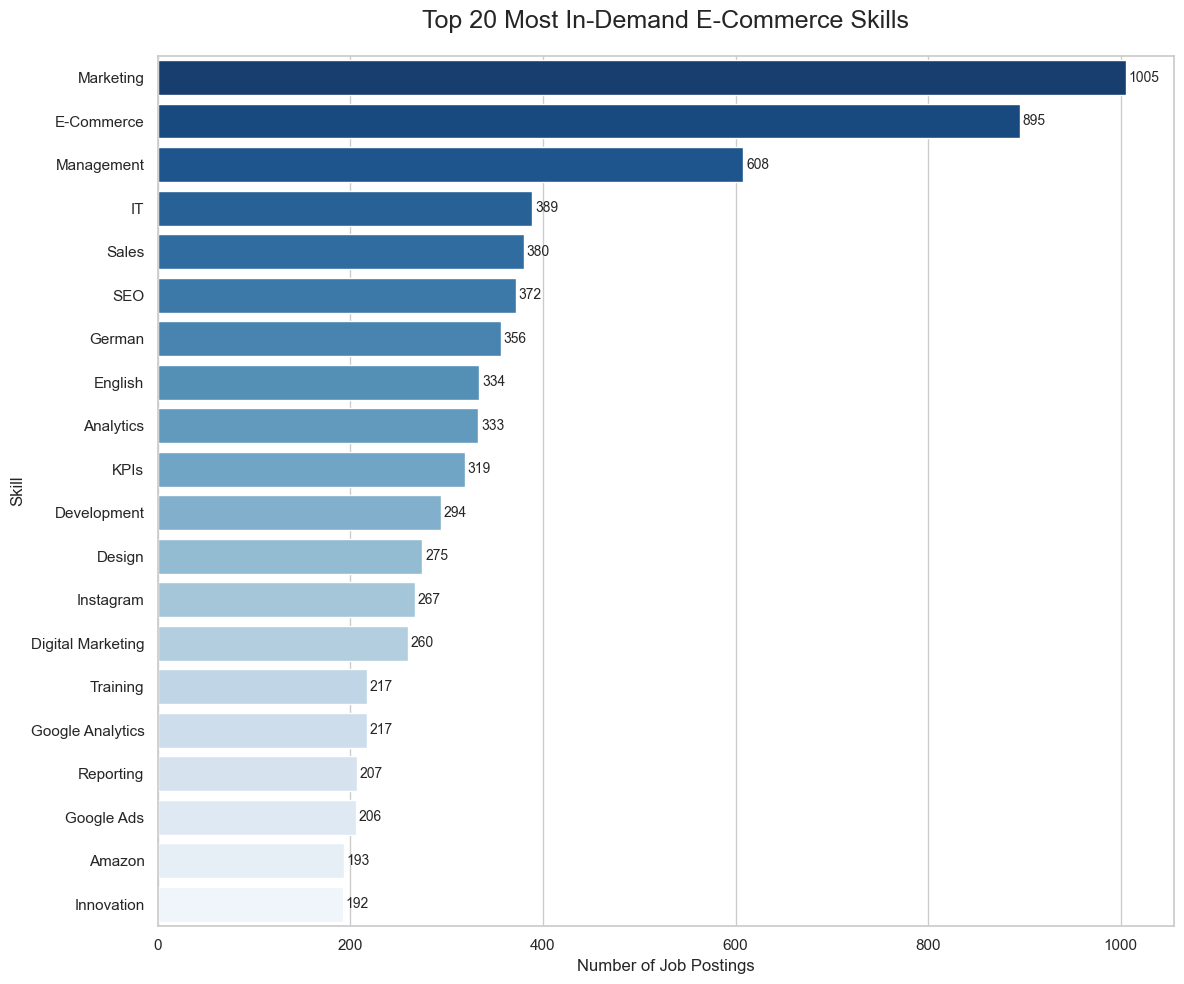

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'
TOP_N = 20 # How many top skills to show

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Skills ---
# 'explode' is a powerful pandas function.
# It takes a list-like column and "unpacks" it,
# creating a new row for each item in the list.
# 
# Before:
# Job 1 | ["E-Commerce", "SEO"]
#
# After:
# Job 1 | "E-Commerce"
# Job 1 | "SEO"

print("Analyzing skills... (exploding lists and counting)")
# Explode the 'Skills' column
skills_series = df.explode('Skills')

# Drop any 'None' or 'NaN' values that might have resulted
skills_cleaned = skills_series.dropna(subset=['Skills'])

# Count the frequency of each skill
skill_counts = skills_cleaned['Skills'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Select the Top N skills and format as a DataFrame
top_skills_df = skill_counts.head(TOP_N).reset_index()
top_skills_df.columns = ['Skill', 'Count']

print(f"\n--- Top {TOP_N} Skills ---")
print(top_skills_df)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid") # Set a nice theme

# Create the figure
plt.figure(figsize=(12, 10)) # (width, height) in inches

# Create the bar plot using seaborn
# We use a reversed palette (e.g., "Blues_r") so the
# top skill (highest count) gets the darkest color.
ax = sns.barplot(
    x='Count', 
    y='Skill', 
    data=top_skills_df, 
    palette="Blues_r" # You can change this to "Greens_r", "Reds_r" etc.
)

# --- Step 5: Customize and Save Plot ---
# Set titles and labels
ax.set_title(f'Top {TOP_N} Most In-Demand E-Commerce Skills', fontsize=18, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Skill', fontsize=12)

# --- Add Data Labels (the count) on the bars ---
# This is a great touch for a portfolio
for p in ax.patches:
    width = p.get_width() # Get the width (the count) of the bar
    ax.annotate(
        f'{int(width)}', # The text to display
        (width + 3, p.get_y() + p.get_height() / 2), # Position (x, y)
        ha='left',   # Horizontal alignment
        va='center', # Vertical alignment
        fontsize=10
    )

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Save the figure
output_image = "top_skills_barchart.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

# Show the plot
plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Counted 435 unique skills.
Generating Word Cloud...
Saving plot...
Success! Word Cloud saved as 'skills_word_cloud.png'


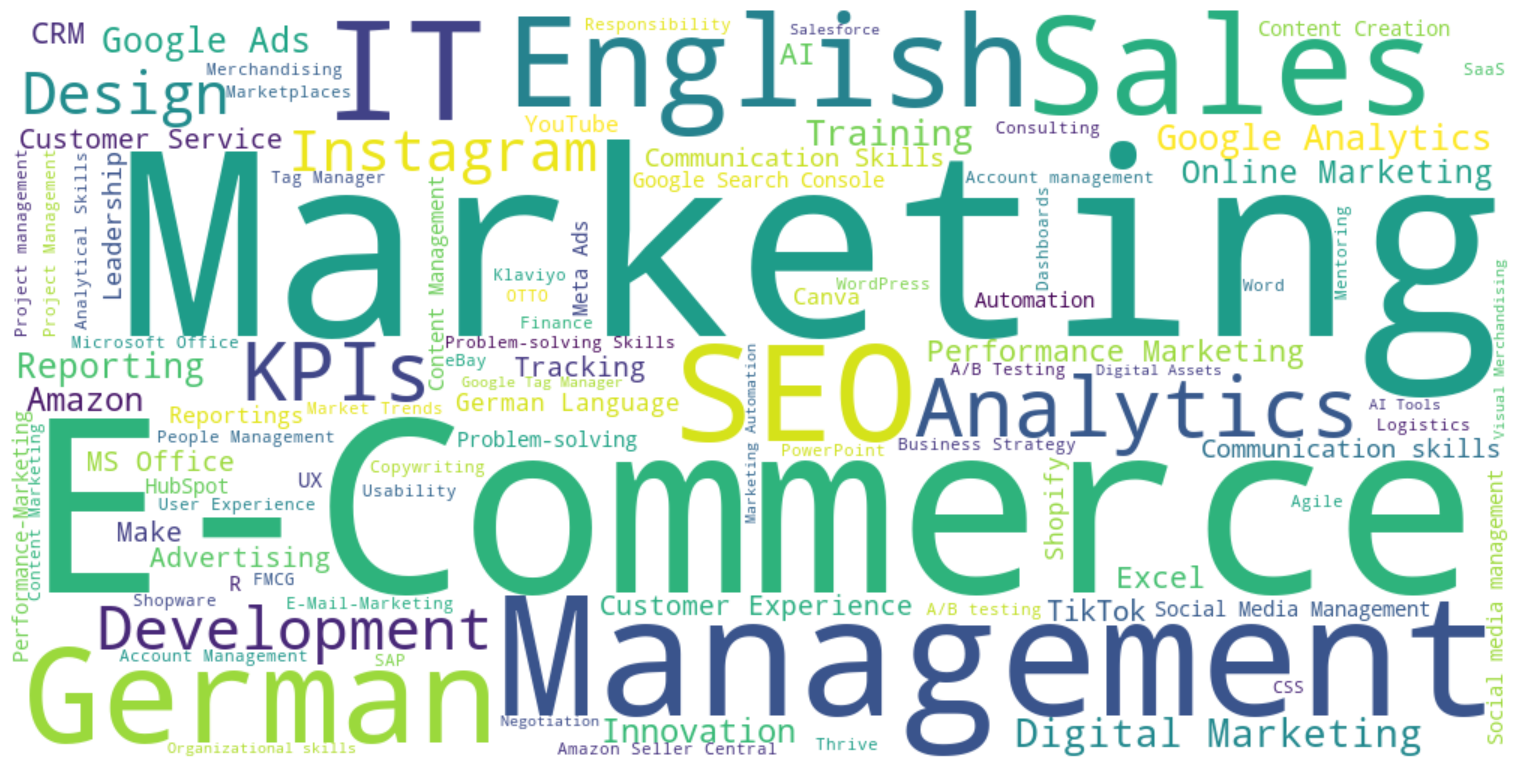

In [7]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Skills ---
# Explode the 'Skills' column to count each skill individually
skills_series = df.explode('Skills')

# Drop any 'None' or 'NaN' values
skills_cleaned = skills_series.dropna(subset=['Skills'])

# Count the frequency of each skill
skill_counts = skills_cleaned['Skills'].value_counts()

# Check if we have any skills to plot
if skill_counts.empty:
    print("No skills found in the data. Exiting.")
    exit()

# Convert the pandas Series to a dictionary
# (The WordCloud library prefers a frequency dictionary)
skills_dict = skill_counts.to_dict()

print(f"Counted {len(skills_dict)} unique skills.")

# --- Step 3: Generate the Word Cloud ---
print("Generating Word Cloud...")

# Initialize the WordCloud object
# You can customize these settings
wordcloud = WordCloud(
    width=1000,                  # Width of the image
    height=500,                 # Height of the image
    background_color='white',   # Background color
    colormap='viridis',         # Colormap for the text (try 'plasma', 'inferno', 'Blues')
    max_words=100,              # Max number of words to display
    contour_width=1,
    contour_color='steelblue',
    collocations=False          # Avoids combining words (e.g., "Digital" and "Marketing")
)

# Generate the cloud from our skill frequencies
wordcloud.generate_from_frequencies(skills_dict)

# --- Step 4: Display and Save the Plot ---
print("Saving plot...")
plt.figure(figsize=(15, 8)) # Set the size of the plot window
plt.imshow(
    wordcloud, 
    interpolation='bilinear' # This makes the text smoother
)
plt.axis('off') # Hide the X and Y axes
plt.tight_layout(pad=0) # Remove extra padding

# Save the figure
output_image = "skills_word_cloud.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Word Cloud saved as '{output_image}'")

# Show the plot
plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Counted 435 unique skills.
Generating Word Cloud with frequency-based colors...


C:\Users\iurie\AppData\Local\Temp\ipykernel_21456\645022056.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap_name)


Saving plot...
Success! Word Cloud saved as 'skills_word_cloud_v2.png'


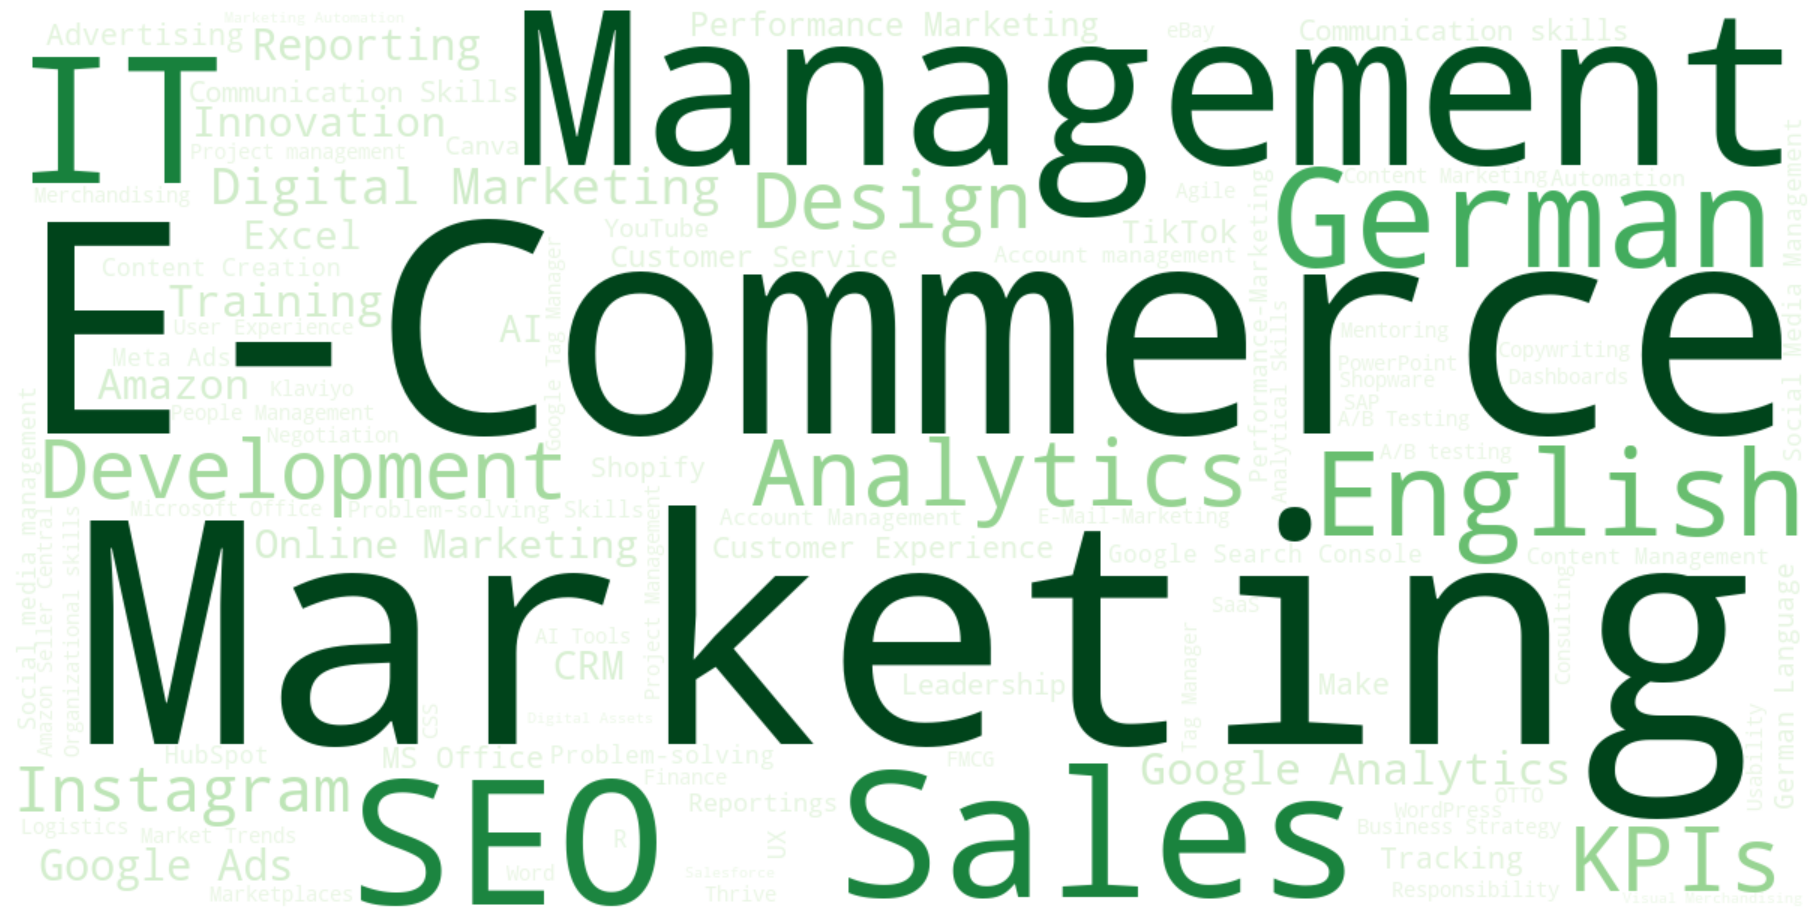

In [9]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # To normalize colors

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Skills ---
skills_series = df.explode('Skills')
skills_cleaned = skills_series.dropna(subset=['Skills'])
skill_counts = skills_cleaned['Skills'].value_counts()

if skill_counts.empty:
    print("No skills found in the data. Exiting.")
    exit()

skills_dict = skill_counts.to_dict()

print(f"Counted {len(skills_dict)} unique skills.")

# --- Step 3: Generate the Word Cloud with Custom Colors ---
print("Generating Word Cloud with frequency-based colors...")

# Define a colormap - for example, 'Purples'.
# We want larger words (higher frequency) to be darker.
# colormap_name = 'Blues'
colormap_name = 'Greens' # You can try 'Blues', 'Purples', 'YlGn', etc.

# Create a colormap object
cmap = plt.cm.get_cmap(colormap_name)

# --- Custom color function ---
# This function will be passed to WordCloud.
# It receives word, font_size, position, orientation, random_state, and **kwargs.
# It should return an RGB tuple or an RGBA tuple, or a string color name.
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # 'word' is the actual text
    # 'font_size' is the size calculated by WordCloud based on frequency
    # We will use 'font_size' to determine the color
    
    # Normalize font_size to be between 0 and 1 for the colormap
    # We'll assume font_size varies, so we need to map it to our colormap range.
    # We use some heuristic here, adjust `max_font_size` if needed
    max_font_size = 150 # Estimate a typical max font size for your data
    normalized_size = min(1.0, font_size / max_font_size)
    
    # Get color from colormap (cmap returns RGBA tuple 0-1)
    rgba_color = cmap(normalized_size)
    
    # Convert RGBA to RGB tuple (0-255) for WordCloud's custom_color_func
    # WordCloud's default color_func expects 0-255 for RGB.
    return 'rgb({},{},{})'.format(
        int(rgba_color[0]*255), 
        int(rgba_color[1]*255), 
        int(rgba_color[2]*255)
    )

# You can also use a simpler approach if you want darker for bigger:
# def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
#     # Get a color from the colormap. Normalize font_size (bigger font = darker color).
#     # Invert for colormaps that go light to dark, like 'Blues'
#     # Example: If font_size is large, normalized_size is large, cmap(large) is dark.
#     max_font_size = 150 # Adjust this based on your output
#     color_value = font_size / max_font_size # Scale font_size to 0-1
#     color_value = min(1.0, max(0.0, color_value)) # Clamp between 0 and 1
#     rgb = cmap(color_value)[:3] # Get RGB values (0-1)
#     return 'rgb({},{},{})'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))


# Initialize the WordCloud object
wordcloud = WordCloud(
    width=1200,                  # Width of the image (adjusted for more space)
    height=600,                 # Height of the image (adjusted)
    background_color='white',   # Background color
    colormap=colormap_name,     # Pass the colormap name here, but the color_func will override
    max_words=100,              # Max number of words to display
    contour_width=1,
    contour_color='gray',       # Changed contour color for better contrast
    collocations=False,         # Avoids combining words
    random_state=42,            # For reproducibility
    color_func=color_func       # Apply our custom color function
)

# Generate the cloud from our skill frequencies
wordcloud.generate_from_frequencies(skills_dict)

# --- Step 4: Display and Save the Plot ---
print("Saving plot...")
plt.figure(figsize=(18, 9)) # Adjust figure size to fit the cloud
plt.imshow(
    wordcloud, 
    interpolation='bilinear'
)
plt.axis('off')
plt.tight_layout(pad=0)

output_image = "skills_word_cloud_v2.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Word Cloud saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Counted 435 unique skills.
Generating Word Cloud (Reversed Colors)...
Saving plot...
Success! Word Cloud saved as 'skills_word_cloud_v3_reversed.png'


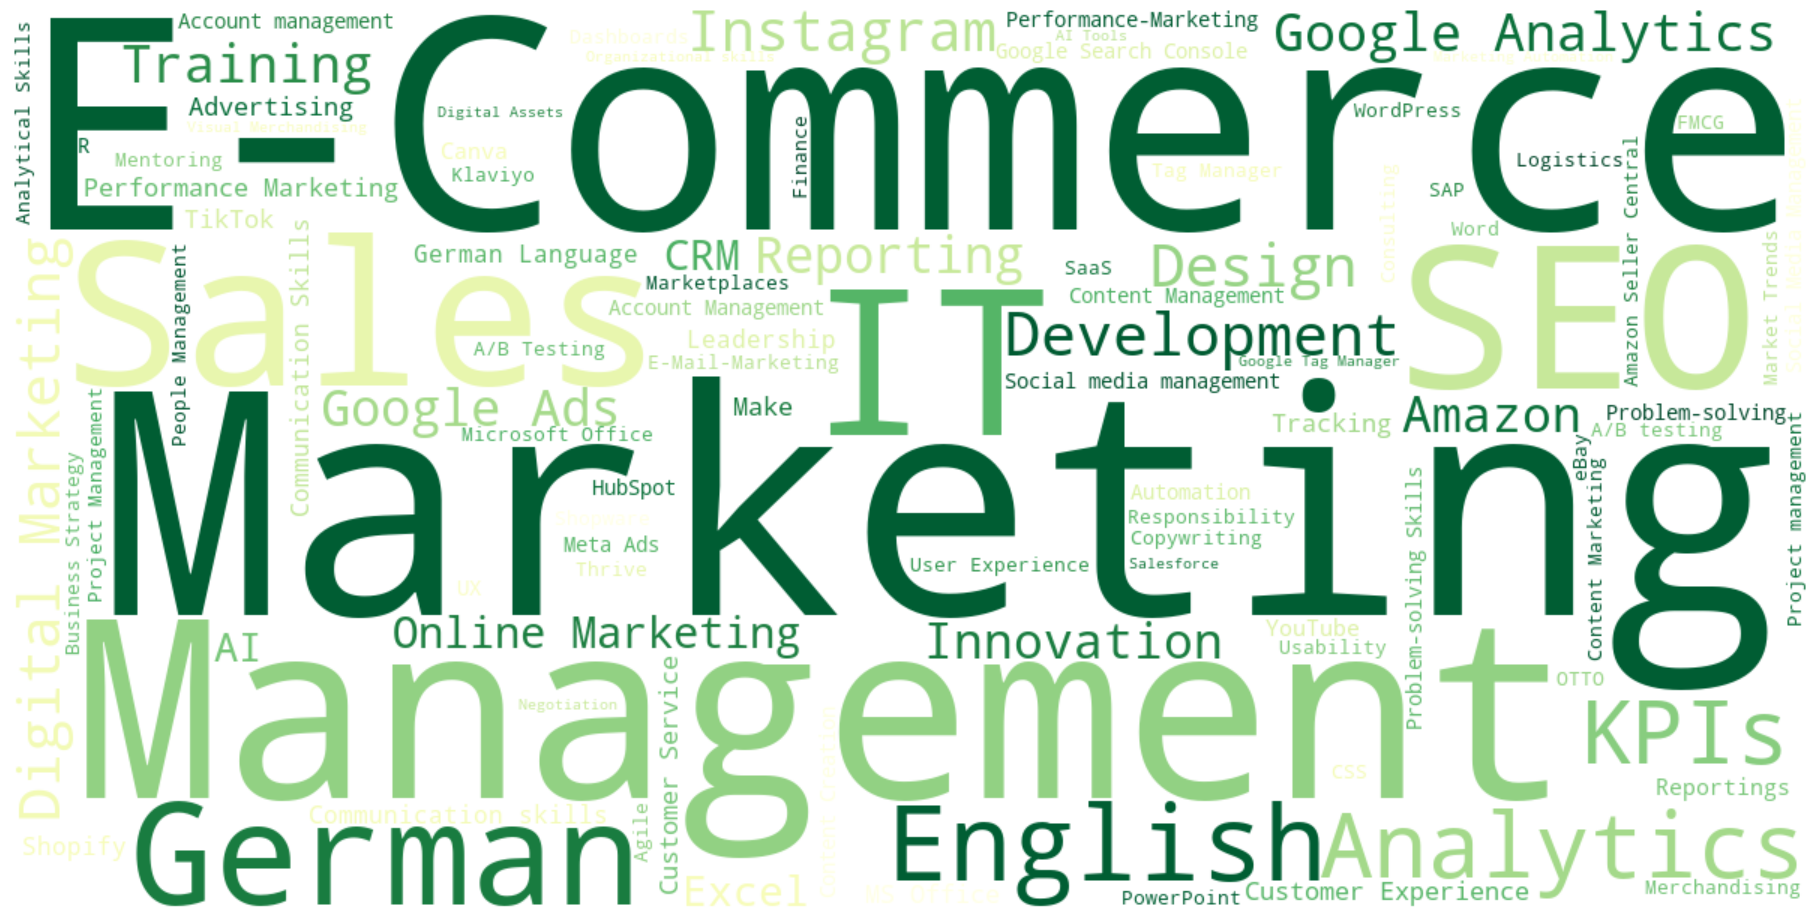

In [10]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Skills ---
skills_series = df.explode('Skills')
skills_cleaned = skills_series.dropna(subset=['Skills'])
skill_counts = skills_cleaned['Skills'].value_counts()

if skill_counts.empty:
    print("No skills found in the data. Exiting.")
    exit()

skills_dict = skill_counts.to_dict()

print(f"Counted {len(skills_dict)} unique skills.")

# --- Step 3: Generate the Word Cloud ---
print("Generating Word Cloud (Reversed Colors)...")

# --- MODIFICATION HERE ---
# We use a REVERSED colormap (e.g., 'YlGn_r').
# The 'r' suffix means "reversed".
# Low frequency (small word) = Dark color (start of _r map)
# High frequency (big word) = Light color (end of _r map)
colormap_name = 'YlGn_r' 
# You can also try: 'Greens_r', 'Blues_r', 'Purples_r'

# Initialize the WordCloud object
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap=colormap_name,     # Using the reversed colormap
    max_words=100,
    contour_width=1,
    contour_color='gray',
    collocations=False,
    random_state=42             # For reproducible layout
    # We REMOVED the custom 'color_func'
)

# Generate the cloud from our skill frequencies
wordcloud.generate_from_frequencies(skills_dict)

# --- Step 4: Display and Save the Plot ---
print("Saving plot...")
plt.figure(figsize=(18, 9))
plt.imshow(
    wordcloud, 
    interpolation='bilinear'
)
plt.axis('off')
plt.tight_layout(pad=0)

output_image = "skills_word_cloud_v3_reversed.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Word Cloud saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Counted 435 unique skills.
Generating Word Cloud with frequency-based colors...


C:\Users\iurie\AppData\Local\Temp\ipykernel_21456\3702917226.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap_name)


Saving plot...
Success! Word Cloud saved as 'skills_word_cloud_YlGn.png'


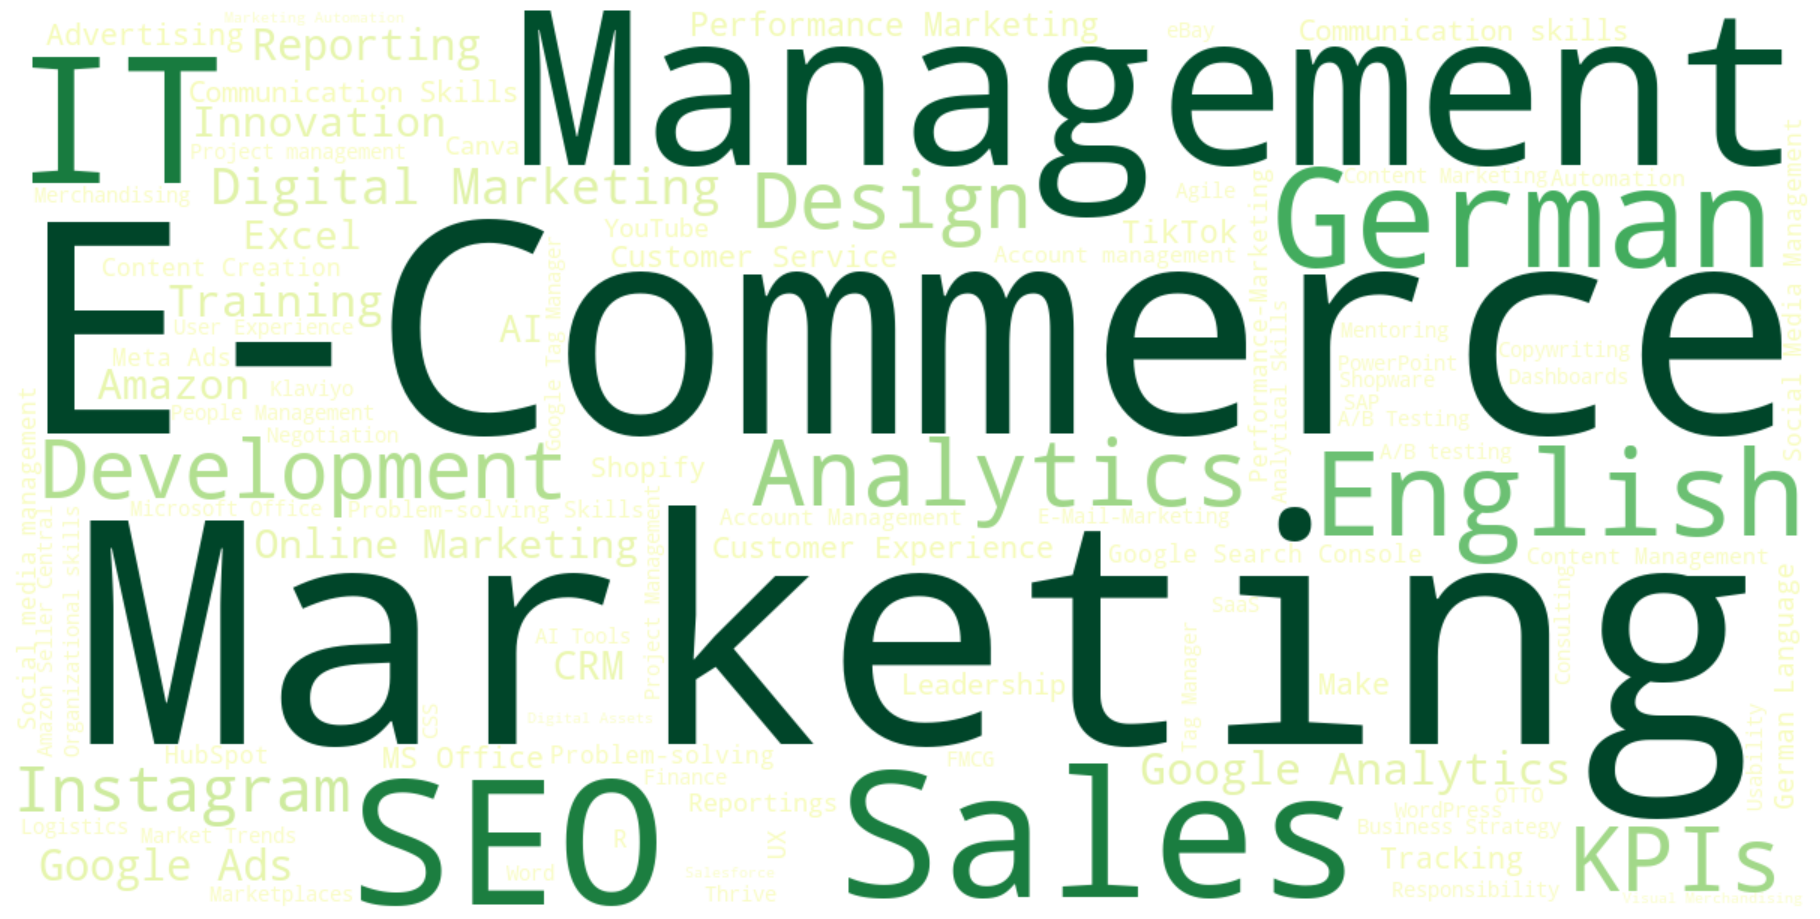

In [11]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # To normalize colors

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Skills ---
skills_series = df.explode('Skills')
skills_cleaned = skills_series.dropna(subset=['Skills'])
skill_counts = skills_cleaned['Skills'].value_counts()

if skill_counts.empty:
    print("No skills found in the data. Exiting.")
    exit()

skills_dict = skill_counts.to_dict()

print(f"Counted {len(skills_dict)} unique skills.")

# --- Step 3: Generate the Word Cloud with Custom Colors ---
print("Generating Word Cloud with frequency-based colors...")

# --- MODIFICATION HERE ---
# We use 'YlGn' (Yellow-Green) just like in the map.
# Small words (low freq) will be Yellow.
# Large words (high freq) will be Dark Green.
colormap_name = 'YlGn' 
# -------------------------

# Create a colormap object
cmap = plt.cm.get_cmap(colormap_name)

# --- Custom color function ---
# This function will be passed to WordCloud.
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # 'font_size' is calculated by WordCloud based on frequency.
    # We will use 'font_size' to determine the color.
    
    # Normalize font_size to be between 0 and 1 for the colormap.
    # This is a heuristic, adjust 'max_font_size' if needed.
    max_font_size = 150 # Estimate a typical max font size for your data
    
    # Ensure normalization maps smaller fonts towards the start (yellow)
    # and larger fonts towards the end (green).
    normalized_size = min(1.0, max(0.0, font_size / max_font_size))
    
    # Get color from colormap (cmap returns RGBA tuple 0-1)
    rgba_color = cmap(normalized_size)
    
    # Convert RGBA to RGB tuple (0-255) for WordCloud
    return 'rgb({},{},{})'.format(
        int(rgba_color[0]*255), 
        int(rgba_color[1]*255), 
        int(rgba_color[2]*255)
    )

# Initialize the WordCloud object
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap=colormap_name, # Pass name, but color_func will override
    max_words=100,
    contour_width=1,
    contour_color='gray',
    collocations=False,
    random_state=42,
    color_func=color_func # Apply our custom color function
)

# Generate the cloud from our skill frequencies
wordcloud.generate_from_frequencies(skills_dict)

# --- Step 4: Display and Save the Plot ---
print("Saving plot...")
plt.figure(figsize=(18, 9))
plt.imshow(
    wordcloud, 
    interpolation='bilinear'
)
plt.axis('off')
plt.tight_layout(pad=0)

output_image = "skills_word_cloud_YlGn.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Word Cloud saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing experience levels...
Filtered out 'N/A' category.

--- Experience Level Counts (Filtered) ---
   Experience Level  Count
0       Entry level    593
1  Mid-Senior level    566
2         Associate    172
3    Not Applicable     89
4        Internship     49
5     Not specified     49
7          Director     21
8         Executive      6

Generating plot...
Success! Chart saved as 'experience_level_barchart_v2.png'


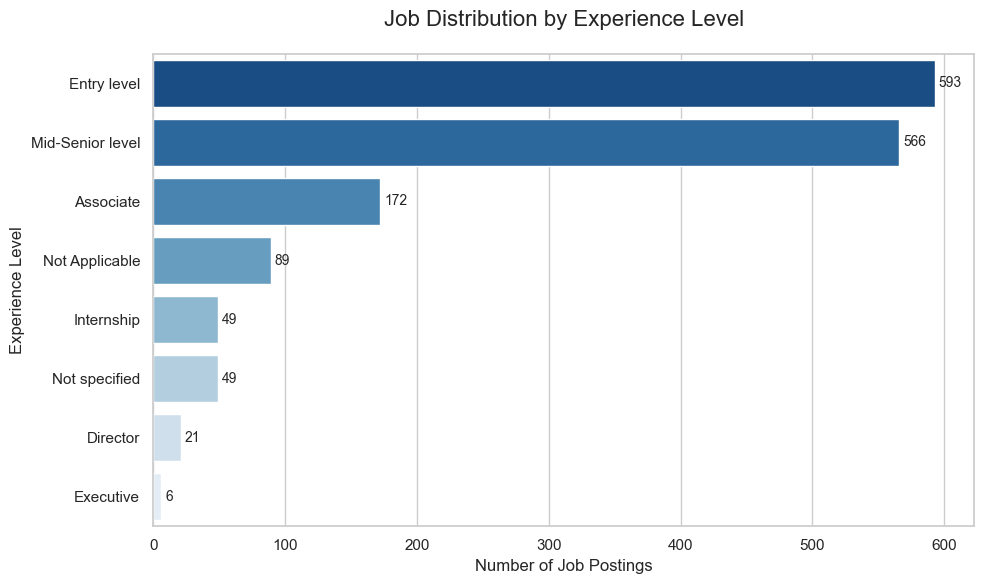

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Experience Levels ---

# Handle missing or empty values
df['Experience'] = df['Experience'].fillna('Not specified')
df['Experience'] = df['Experience'].replace('', 'Not specified')

print("Analyzing experience levels...")
# Count the frequency
experience_counts = df['Experience'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
exp_df = experience_counts.reset_index()
exp_df.columns = ['Experience Level', 'Count']

# --- MODIFICATION 1: Filter out 'N/A' ---
# We remove the 'N/A' category before plotting
exp_df_filtered = exp_df[exp_df['Experience Level'] != 'N/A'].copy()
print("Filtered out 'N/A' category.")

print("\n--- Experience Level Counts (Filtered) ---")
print(exp_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# --- MODIFICATION 2: Fix FutureWarning ---
# We add 'hue' and 'legend=False' as requested by the warning
ax = sns.barplot(
    x='Count', 
    y='Experience Level', 
    data=exp_df_filtered, # Use the filtered data
    palette="Blues_r",
    hue='Experience Level', # Assign y-variable to hue
    legend=False          # Disable the redundant legend
)
# ---------------------------------------------

# --- Step 5: Customize and Save Plot ---
ax.set_title('Job Distribution by Experience Level', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Experience Level', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

plt.tight_layout()

# Save the figure
output_image = "experience_level_barchart_v2.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing job types...
Filtered out: ['Not specified']

--- Job Type Counts (Filtered) ---
             Job Type  Count
0           Full-time   1345
1           Part-time    119
3            Contract     31
4          Internship     31
5               Other      9
6           Temporary      1
7  Apprentice/Trainee      1

Generating plot...
Success! Chart saved as 'job_type_barchart_v2.png'


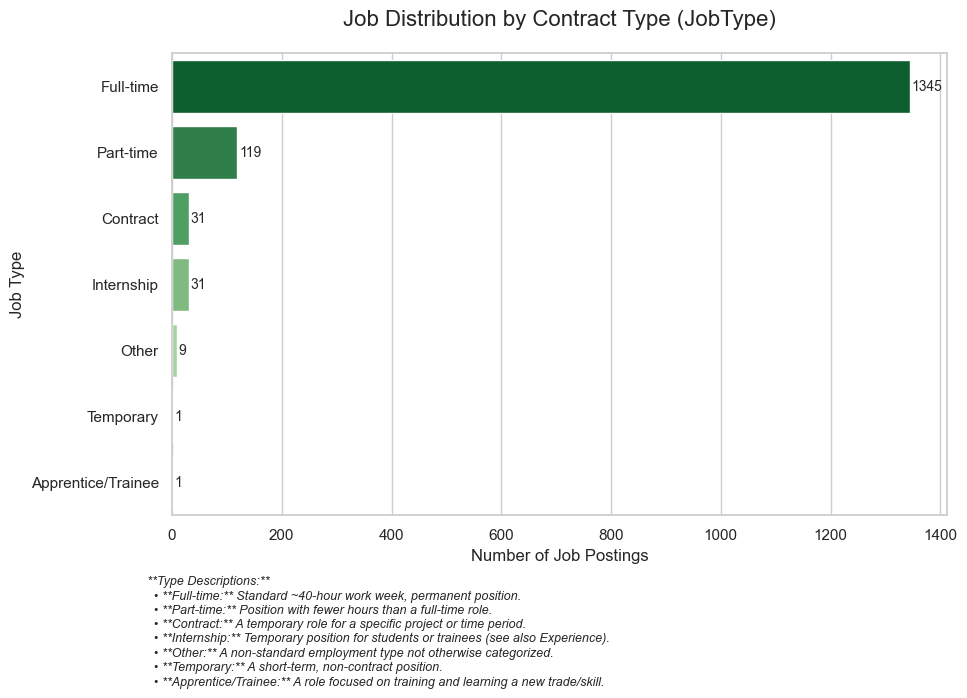

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Job Types ---

# Handle missing or empty values
df['JobType'] = df['JobType'].fillna('Not specified')
df['JobType'] = df['JobType'].replace('', 'Not specified')
df['JobType'] = df['JobType'].replace('N/A', 'Not specified') # Group N/A

print("Analyzing job types...")
# Count the frequency
job_type_counts = df['JobType'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
job_type_df = job_type_counts.reset_index()
job_type_df.columns = ['Job Type', 'Count']

# --- Filter out categories ---
# We'll remove 'Not specified' from the plot
exclude_list = ['Not specified']
job_type_df_filtered = job_type_df[~job_type_df['Job Type'].isin(exclude_list)].copy()
print(f"Filtered out: {exclude_list}")

print("\n--- Job Type Counts (Filtered) ---")
print(job_type_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust size if needed

# Fix for seaborn FutureWarning
ax = sns.barplot(
    x='Count', 
    y='Job Type', 
    data=job_type_df_filtered, # Use the filtered data
    palette="Greens_r", 
    hue='Job Type', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Job Distribution by Contract Type (JobType)', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Job Type', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# --- MODIFICATION: Add left-aligned explanation text ---
# Create the explanation string
explanation_string = (
    "**Type Descriptions:**\n"
    "  • **Full-time:** Standard ~40-hour work week, permanent position.\n"
    "  • **Part-time:** Position with fewer hours than a full-time role.\n"
    "  • **Contract:** A temporary role for a specific project or time period.\n"
    "  • **Internship:** Temporary position for students or trainees (see also Experience).\n"
    "  • **Other:** A non-standard employment type not otherwise categorized.\n"
    "  • **Temporary:** A short-term, non-contract position.\n"
    "  • **Apprentice/Trainee:** A role focused on training and learning a new trade/skill."
)

# Add the text to the figure, positioned at the bottom-left
fig.text(0.1, 0.01, explanation_string, ha="left", va="top", fontsize=9, style='italic', wrap=True)
# -----------------------------------------------------------


# Save the figure
output_image = "job_type_barchart_v2.png"
# We must use bbox_inches='tight' to ensure the figtext is included
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing experience levels...
Filtered out: ['N/A', 'Not specified', 'Not Applicable']

--- Experience Level Counts (Filtered) ---
   Experience Level  Count
0       Entry level    593
1  Mid-Senior level    566
2         Associate    172
4        Internship     49
7          Director     21
8         Executive      6

Generating plot...
Success! Chart saved as 'experience_level_barchart_v4.png'


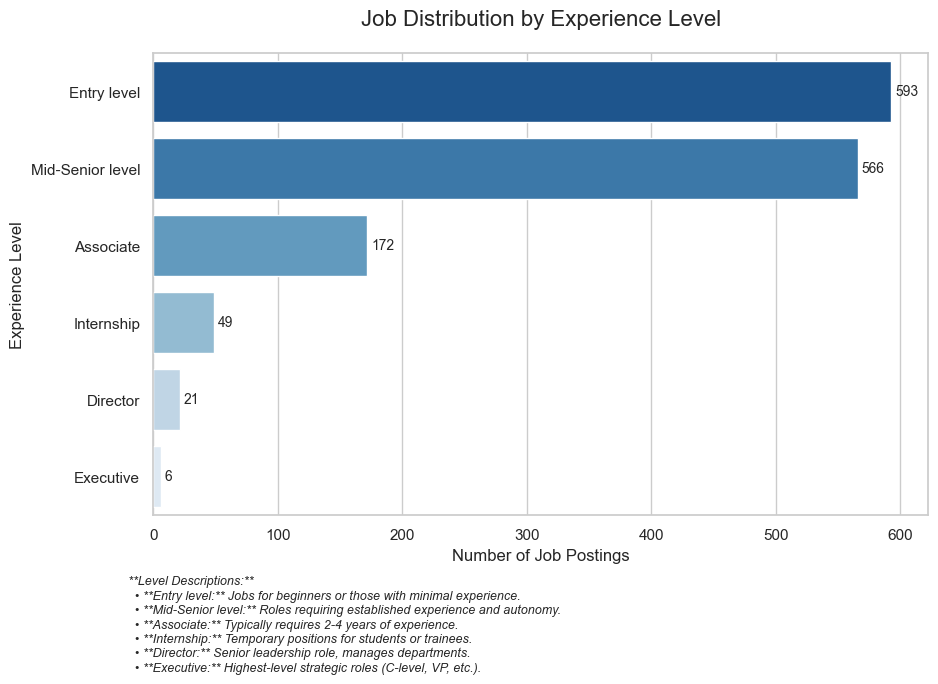

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Experience Levels ---

# Handle missing or empty values
df['Experience'] = df['Experience'].fillna('Not specified')
df['Experience'] = df['Experience'].replace('', 'Not specified')

print("Analyzing experience levels...")
# Count the frequency
experience_counts = df['Experience'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
exp_df = experience_counts.reset_index()
exp_df.columns = ['Experience Level', 'Count']

# Define a list of categories to exclude from the plot
exclude_list = ['N/A', 'Not specified', 'Not Applicable']
exp_df_filtered = exp_df[~exp_df['Experience Level'].isin(exclude_list)].copy()
print(f"Filtered out: {exclude_list}")

print("\n--- Experience Level Counts (Filtered) ---")
print(exp_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Fix for seaborn FutureWarning
ax = sns.barplot(
    x='Count', 
    y='Experience Level', 
    data=exp_df_filtered, # Use the filtered data
    palette="Blues_r",
    hue='Experience Level', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Job Distribution by Experience Level', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Experience Level', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# --- MODIFICATION: Add left-aligned explanation text ---
# Create the explanation string
explanation_string = (
    "**Level Descriptions:**\n"
    "  • **Entry level:** Jobs for beginners or those with minimal experience.\n"
    "  • **Mid-Senior level:** Roles requiring established experience and autonomy.\n"
    "  • **Associate:** Typically requires 2-4 years of experience.\n"
    "  • **Internship:** Temporary positions for students or trainees.\n"
    "  • **Director:** Senior leadership role, manages departments.\n"
    "  • **Executive:** Highest-level strategic roles (C-level, VP, etc.)."
)

# Add the text to the figure, positioned at the bottom-left
# We set x=0.1 (10% from the left) and ha="left"
fig.text(0.1, 0.01, explanation_string, ha="left", va="top", fontsize=9, style='italic', wrap=True)
# -----------------------------------------------------------

# Save the figure
output_image = "experience_level_barchart_v4.png"
# We must use bbox_inches='tight' to ensure the figtext is included
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing work types...
Wrapped long labels at 30 characters.

--- Top 15 Work Type Counts (Filtered) ---
                                            Work Type  Count
0                                           Marketing    411
1                                 Marketing and Sales    196
2                                               Other    137
3                                    Customer Service    115
4                      Sales and Business Development    112
5                                               Sales    102
6   Marketing, Public Relations,\nand Writing/Editing     59
7                              Information Technology     50
9                        Management and Manufacturing     40
10                                     Administrative     34
11                Sales, Other, and Customer\nService     13
12                             Education and Training     13
13                           

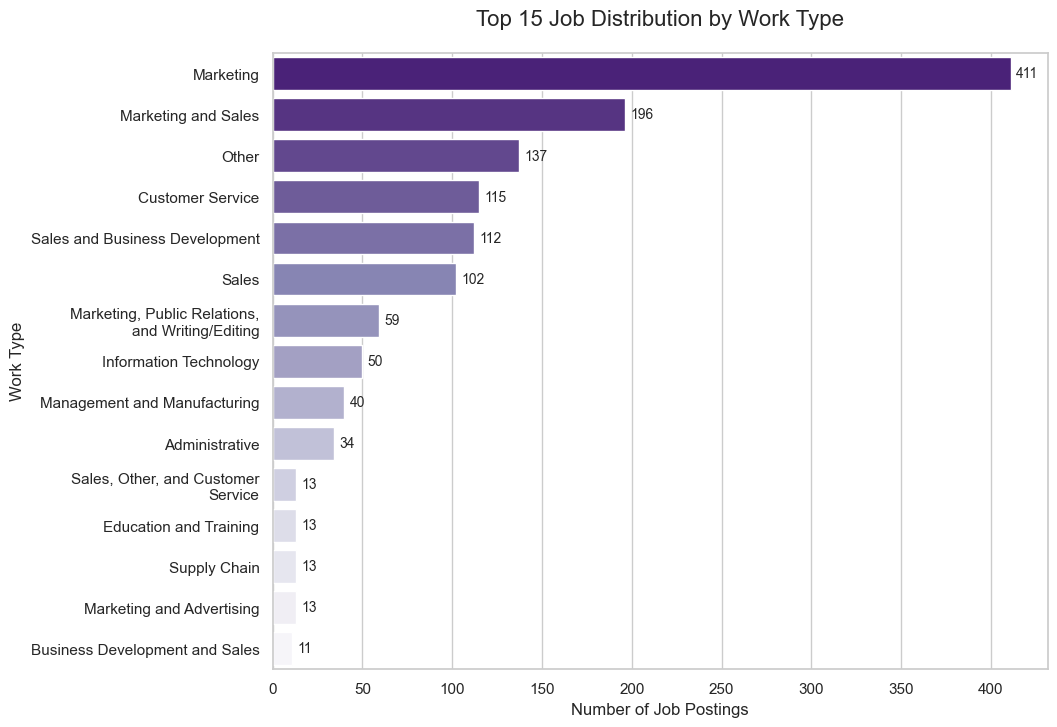

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap # We import the textwrap library

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Work Types ---

# Handle missing or empty values
df['WorkType'] = df['WorkType'].fillna('Not specified')
df['WorkType'] = df['WorkType'].replace('', 'Not specified')
df['WorkType'] = df['WorkType'].replace('N/A', 'Not specified') # Group N/A

print("Analyzing work types...")
# Count the frequency
work_type_counts = df['WorkType'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
work_type_df = work_type_counts.reset_index()
work_type_df.columns = ['Work Type', 'Count']

# Filter out categories
exclude_list = ['Not specified']
work_type_df_filtered = work_type_df[~work_type_df['Work Type'].isin(exclude_list)].copy()

# Plot the Top 15
TOP_N = 15
work_type_df_filtered = work_type_df_filtered.head(TOP_N)

# --- MODIFICATION: Wrap long labels ---
# We define a width (in characters) to wrap at
WRAP_WIDTH = 30 

# We use textwrap.wrap() to get a list of lines
# Then we join them with the newline character '\n'
work_type_df_filtered['Work Type'] = work_type_df_filtered['Work Type'].apply(
    lambda s: '\n'.join(textwrap.wrap(s, width=WRAP_WIDTH))
)
print(f"Wrapped long labels at {WRAP_WIDTH} characters.")
# ---------------------------------------------

print(f"\n--- Top {TOP_N} Work Type Counts (Filtered) ---")
print(work_type_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(10, 8)) 

# The plot will automatically have more space for bars
# because the y-labels are now "thinner"
ax = sns.barplot(
    x='Count', 
    y='Work Type', 
    data=work_type_df_filtered,
    palette="Purples_r",
    hue='Work Type', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title(f'Top {TOP_N} Job Distribution by Work Type', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Work Type', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# Save the figure
output_image = "work_type_barchart_v3_wrap.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()

Loading data from E_Commers_jobs_done.json...
Loaded 1581 job postings.
Analyzing job types...
Filtered out: ['Not specified']

--- Job Type Counts (Filtered) ---
             Job Type  Count
0           Full-time   1345
1           Part-time    119
3            Contract     31
4          Internship     31
5               Other      9
6           Temporary      1
7  Apprentice/Trainee      1

Generating plot...
Success! Chart saved as 'job_type_barchart_v2.png'


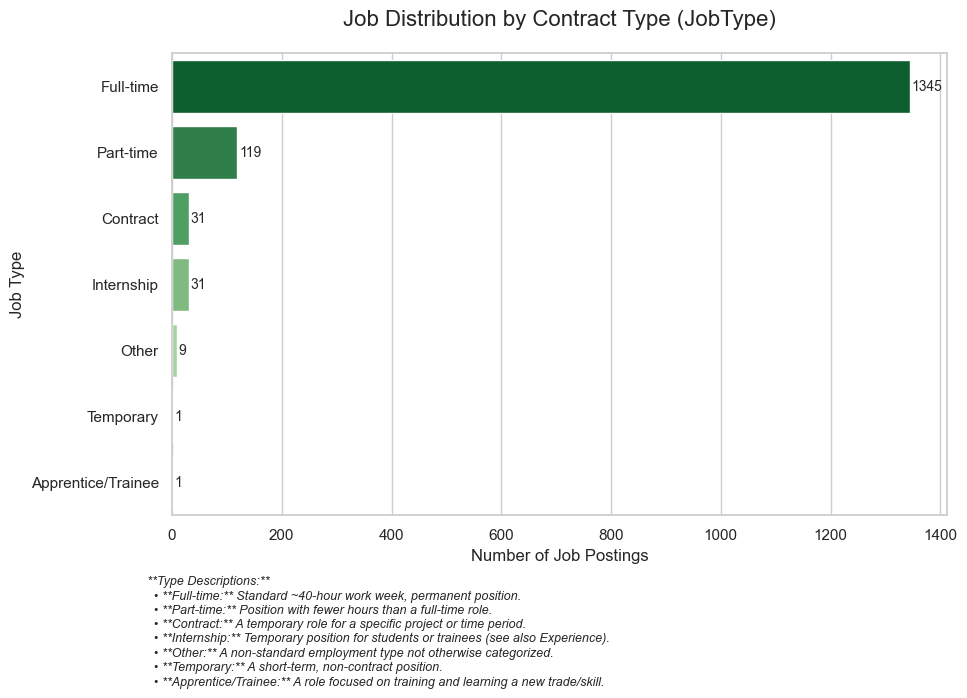

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Load Data ---
FILE_NAME = 'E_Commers_jobs_done.json'

print(f"Loading data from {FILE_NAME}...")
try:
    df = pd.read_json(FILE_NAME)
except FileNotFoundError:
    print(f"Error: {FILE_NAME} not found.")
    exit()
except Exception as e:
    print(f"Error loading JSON: {e}")
    exit()

print(f"Loaded {len(df)} job postings.")

# --- Step 2: Process and Count Job Types ---

# Handle missing or empty values
df['JobType'] = df['JobType'].fillna('Not specified')
df['JobType'] = df['JobType'].replace('', 'Not specified')
df['JobType'] = df['JobType'].replace('N/A', 'Not specified') # Group N/A

print("Analyzing job types...")
# Count the frequency
job_type_counts = df['JobType'].value_counts()

# --- Step 3: Prepare Data for Plotting ---
# Format as a DataFrame
job_type_df = job_type_counts.reset_index()
job_type_df.columns = ['Job Type', 'Count']

# --- Filter out categories ---
# We'll remove 'Not specified' from the plot
exclude_list = ['Not specified']
job_type_df_filtered = job_type_df[~job_type_df['Job Type'].isin(exclude_list)].copy()
print(f"Filtered out: {exclude_list}")

print("\n--- Job Type Counts (Filtered) ---")
print(job_type_df_filtered)

# --- Step 4: Create the Horizontal Bar Chart ---
print("\nGenerating plot...")
sns.set_theme(style="whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust size if needed

# Fix for seaborn FutureWarning
ax = sns.barplot(
    x='Count', 
    y='Job Type', 
    data=job_type_df_filtered, # Use the filtered data
    palette="Greens_r", 
    hue='Job Type', 
    legend=False          
)

# --- Step 5: Customize and Save Plot ---
ax.set_title('Job Distribution by Contract Type (JobType)', fontsize=16, pad=20)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Job Type', fontsize=12)

# Add Data Labels (the count) on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        (width + 3, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

# --- MODIFICATION: Add left-aligned explanation text ---
# Create the explanation string
explanation_string = (
    "**Type Descriptions:**\n"
    "  • **Full-time:** Standard ~40-hour work week, permanent position.\n"
    "  • **Part-time:** Position with fewer hours than a full-time role.\n"
    "  • **Contract:** A temporary role for a specific project or time period.\n"
    "  • **Internship:** Temporary position for students or trainees (see also Experience).\n"
    "  • **Other:** A non-standard employment type not otherwise categorized.\n"
    "  • **Temporary:** A short-term, non-contract position.\n"
    "  • **Apprentice/Trainee:** A role focused on training and learning a new trade/skill."
)

# Add the text to the figure, positioned at the bottom-left
fig.text(0.1, 0.01, explanation_string, ha="left", va="top", fontsize=9, style='italic', wrap=True)
# -----------------------------------------------------------


# Save the figure
output_image = "job_type_barchart_v2.png"
# We must use bbox_inches='tight' to ensure the figtext is included
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Success! Chart saved as '{output_image}'")

plt.show()